**Practical 2 - Understanding Foundation of Stats using Rating Dataset**

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/TeachingRatings.csv")
df

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5
...,...,...,...,...,...,...,...,...,...,...,...,...
458,no,32,male,more,1.231394,3.2,lower,yes,yes,9,21,93
459,no,32,male,more,1.231394,4.3,upper,yes,yes,52,86,93
460,yes,42,female,more,0.420400,3.3,upper,no,yes,52,67,94
461,yes,42,female,more,0.420400,3.2,upper,no,yes,54,66,94


In [ ]:
df.head(10)

,minority,age,gender,credits,beauty,eval,division,native,tenure,students,allstudents,prof
0,yes,36,female,more,0.289916,4.3,upper,yes,yes,24,43,1
1,no,59,male,more,-0.737732,4.5,upper,yes,yes,17,20,2
2,no,51,male,more,-0.571984,3.7,upper,yes,yes,55,55,3
3,no,40,female,more,-0.677963,4.3,upper,yes,yes,40,46,4
4,no,31,female,more,1.509794,4.4,upper,yes,yes,42,48,5
5,no,62,male,more,0.588569,4.2,upper,yes,yes,182,282,6
6,no,33,female,more,-0.126001,4.0,upper,yes,yes,33,41,7
7,no,51,female,more,-0.258190,3.4,upper,yes,yes,25,41,8
8,no,33,female,more,0.149693,4.5,upper,yes,yes,48,60,9
9,no,47,male,more,0.540917,3.9,upper,yes,no,16,19,10


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   minority     463 non-null    object 
 1   age          463 non-null    int64  
 2   gender       463 non-null    object 
 3   credits      463 non-null    object 
 4   beauty       463 non-null    float64
 5   eval         463 non-null    float64
 6   division     463 non-null    object 
 7   native       463 non-null    object 
 8   tenure       463 non-null    object 
 9   students     463 non-null    int64  
 10  allstudents  463 non-null    int64  
 11  prof         463 non-null    int64  
dtypes: float64(2), int64(4), object(6)
memory usage: 43.5+ KB


In [ ]:
df.columns

Index(['minority', 'age', 'gender', 'credits', 'beauty', 'eval', 'division',
       'native', 'tenure', 'students', 'allstudents', 'prof'],
      dtype='object')

**Q-1** This is a cross-sectional data. The dataset contains information about different professors, such as their gender, beauty score, student rating, and tenure status. The professors are not being obsserved repeatedly over different time periods. Therefore, it is cross-sectional rather than time-series data.

**Q-2**

In [ ]:
students = df["students"]
print("Mean =", students.mean())
print("Median =", students.median())
print("Minimum =", students.min())
print("Maximum =", students.max())

Mean = 36.62419006479482
Median = 23.0
Minimum = 5
Maximum = 380


**Q-3**

In [ ]:
df.describe()

,age,beauty,eval,students,allstudents,prof
count,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000
mean,48.365011,6.263499e-08,3.998272,36.624190,55.177106,45.434125
std,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902
min,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000
25%,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000
50%,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000
75%,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000
max,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000


**Q-4**

In [ ]:
import matplotlib.pyplot as plt

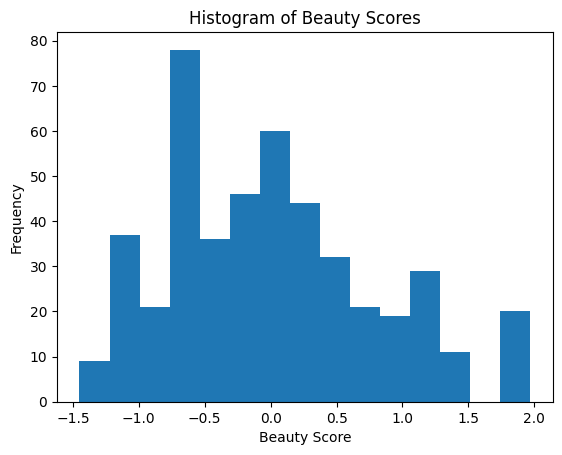

In [ ]:
plt.hist(df["beauty"], bins=15)
plt.xlabel("Beauty Score")
plt.ylabel("Frequency")
plt.title("Histogram of Beauty Scores")
plt.show()

**Comment** - The histogram of beauty scores appears to be roughly unimodal. The distribution is slightly right-skewed, as there is a longer tail towards higher beauty scores, with a few observations above 1.0 and up to around 2.0. There are also some lower scores extending to about-1.5. Thus, the data is not perfectly symmetric and shows a few extreme values at both ends, particularly on the right side.

**Q-5**

In [ ]:
df.groupby("gender")["beauty"].mean()

,beauty
gender,
female,0.116109
male,-0.084482


The average beauty score for female instructors is 0.1161.
The average beauty score for male instructors is -0.0845.
Since 0.1161 > -0.0845, female instructors have a slightly higher average beauty score than male instructors in this dataset.

In [ ]:
df.groupby("gender")["beauty"].std()

,beauty
gender,
female,0.81781
male,0.75713


The standard deviations are: Female: 0.8178 Male: 0.7571.
This indicates that beauty scores among female instructors are slightly more spread out (more variable) than those among male instructors.

**Q-6**

In [ ]:
pd.crosstab(df["gender"], df["tenure"])

tenure,no,yes
gender,,
female,50,145
male,52,216


In [ ]:
pd.crosstab(
    df["gender"],
    df["tenure"],
    normalize="index"
) * 100

tenure,no,yes
gender,,
female,25.641026,74.358974
male,19.402985,80.597015


Male professors with tenure: 80.60% Female professors with tenure: 74.36% To determine whether tenure status differs by gender, a cross-tabulation of gender and tenure status was performed. The results show that 74.36% of female instructors and 80.60% of male instructors are tenured professors. Since the percentage of tenured male instructors is higher than that of female instructors, tenure status appears to differ somewhat by gender, with males having a higher tenure rate in this dataset. However, a statistical test such as the Chi-Square test would be required to determine whether this difference is statistically significant.